# Customer Churn & Retention Analytics
## Notebook 3: Cohort Analysis & Retention Curves ⭐

### Objective

This notebook analyzes customer retention through the customer lifecycle.

Because the dataset does not contain a signup date or customer acquisition date,
traditional calendar-based cohort analysis is not possible.

Therefore, **Tenure** is used as a lifecycle-based cohort variable.

The analysis focuses on:

- Customer lifecycle stages
- Cohort-level churn and retention
- Satisfaction and complaint patterns
- Customer engagement
- Retention curve
- Survival-style churn analysis
- Customer risk segmentation

No machine learning models are used in this notebook.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import warnings to suppress unnecessary messages
import warnings
warnings.filterwarnings("ignore")

# Set pandas display options
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Set professional visualization style
sns.set_theme(style="whitegrid", context="notebook")

# Define project color scheme
CHURN_COLOR = "#E74C3C"
RETAINED_COLOR = "#2ECC71"
NEUTRAL_COLOR = "#3498DB"

# Define file paths
CLEANED_FILE_PATH = "../data/cleaned/cleaned_ecommerce_churn.csv"
IMAGE_FOLDER = "../reports/images"
RISK_OUTPUT_PATH = "../data/cleaned/customer_risk_segments.csv"

# Create required output folders if they do not exist
import os
os.makedirs(IMAGE_FOLDER, exist_ok=True)
os.makedirs("../data/cleaned", exist_ok=True)

# Print notebook information
print("Customer Churn & Retention Analytics")
print("Notebook 3: Cohort Analysis & Retention Curves")
print("=" * 60)

Customer Churn & Retention Analytics
Notebook 3: Cohort Analysis & Retention Curves


## Load Cleaned Dataset

The cleaned dataset created in Notebook 1 is loaded here.

Notebook 3 does not perform another cleaning process because the dataset has
already been cleaned.

We only verify the shape, missing values, and churn distribution before analysis.

In [7]:
# Load the cleaned dataset
df = pd.read_csv(CLEANED_FILE_PATH)

# Display dataset dimensions
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

# Check total missing values
print(f"Missing Values: {df.isna().sum().sum():,}")

# Display churn distribution
print("\nChurn Distribution:")
display(
    df["Churn"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Retained", 1: "Churned"})
)

Rows    : 5,630
Columns : 22
Missing Values: 0

Churn Distribution:


Churn
Retained    4682
Churned      948
Name: count, dtype: int64

### Analytical Note

This dataset does not contain a signup date.

Therefore:

**Traditional cohort analysis:**
Customers grouped by calendar acquisition month → Not possible.

**Lifecycle cohort analysis:**
Customers grouped by months with company → Used in this notebook.

Tenure therefore represents the customer's lifecycle stage.

## Section 2: Create Tenure Cohort Groups

Customers are grouped into five lifecycle stages based on Tenure:

- **New (0-3m)** → Early onboarding stage
- **Growing (4-6m)** → Early relationship development
- **Established (7-12m)** → Customer relationship stabilization
- **Mature (13-24m)** → Long-term relationship
- **Loyal (25m+)** → Long-tenure customers

This allows us to compare churn and customer behavior across the lifecycle.

In [9]:
# Define the lifecycle order so charts appear logically
tenure_cohort_order = [
    "New (0-3m)",
    "Growing (4-6m)",
    "Established (7-12m)",
    "Mature (13-24m)",
    "Loyal (25m+)"
]

# Create lifecycle cohort based on customer tenure
df["TenureCohort"] = pd.cut(
    df["Tenure"],
    bins=[-np.inf, 3, 6, 12, 24, np.inf],
    labels=tenure_cohort_order,
    include_lowest=True
)

# Convert the cohort column into an ordered categorical variable
df["TenureCohort"] = pd.Categorical(
    df["TenureCohort"],
    categories=tenure_cohort_order,
    ordered=True
)

# Calculate customer count and churn rate by cohort
cohort_summary = (
    df.groupby("TenureCohort", observed=False)
    .agg(
        Customers=("CustomerID", "count"),
        Churned=("Churn", "sum"),
        Churn_Rate=("Churn", "mean")
    )
)

# Convert churn rate into percentage
cohort_summary["Churn_Rate"] = (
    cohort_summary["Churn_Rate"] * 100
)

# Calculate retention rate
cohort_summary["Retention_Rate"] = (
    100 - cohort_summary["Churn_Rate"]
)

# Display cohort summary
display(cohort_summary.round(2))

,Customers,Churned,Churn_Rate,Retention_Rate
TenureCohort,,,,
New (0-3m),1560,653,41.86,58.14
Growing (4-6m),590,44,7.46,92.54
Established (7-12m),1584,156,9.85,90.15
Mature (13-24m),1467,95,6.48,93.52
Loyal (25m+),429,0,0.00,100.00


### Business Insight

The cohort table establishes the baseline lifecycle story.

The most important comparison is between the **New** and **Loyal** cohorts.

If early-stage customers have substantially higher churn, the company should
focus retention efforts on the first few months of the customer relationship.

## Section 3: Cohort Churn Rate Visualization

This visualization compares churn rates across customer lifecycle stages.

A green-to-red gradient is used:
- Green → Lower churn
- Red → Higher churn

The exact percentage is displayed on every bar.

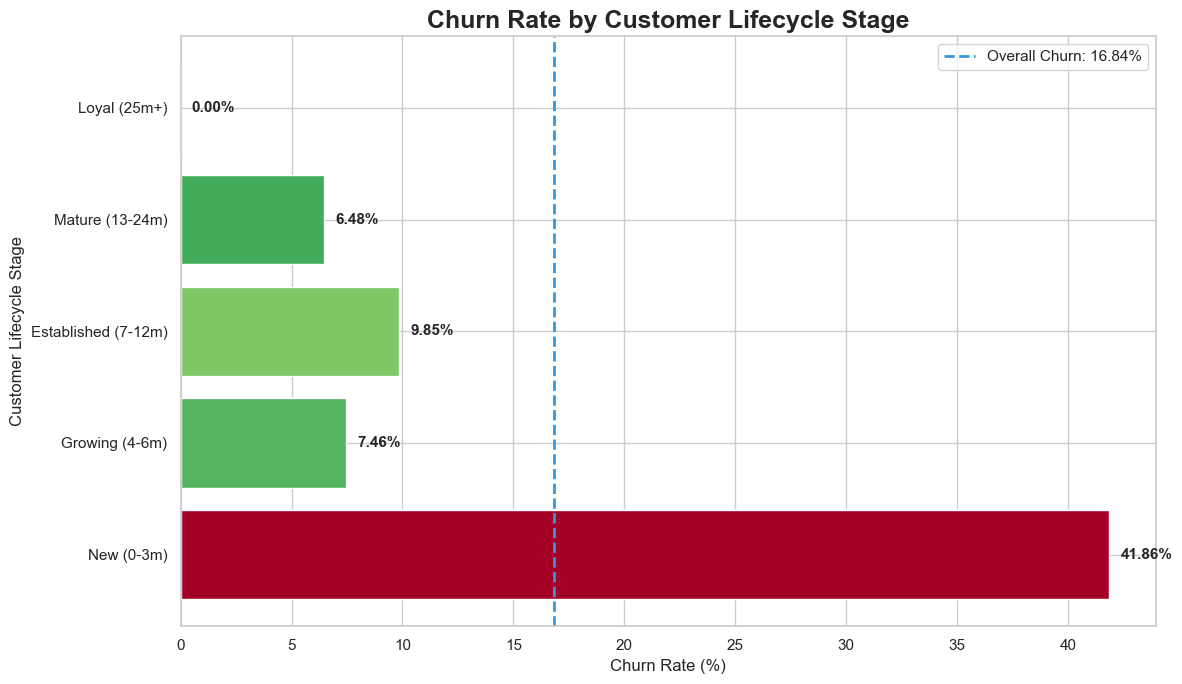

In [11]:
# Extract cohort churn rates
cohort_churn_rates = cohort_summary["Churn_Rate"]

# Normalize values for the green-to-red color gradient
normalized_values = (
    (cohort_churn_rates - cohort_churn_rates.min()) /
    (cohort_churn_rates.max() - cohort_churn_rates.min())
    if cohort_churn_rates.max() != cohort_churn_rates.min()
    else np.zeros(len(cohort_churn_rates))
)

# Create green-to-red colors
cohort_colors = [
    plt.cm.RdYlGn_r(value)
    for value in normalized_values
]

# Create horizontal bar chart
plt.figure(figsize=(12, 7))

bars = plt.barh(
    cohort_churn_rates.index.astype(str),
    cohort_churn_rates.values,
    color=cohort_colors
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Add overall churn benchmark
overall_churn_rate = df["Churn"].mean() * 100

plt.axvline(
    overall_churn_rate,
    color=NEUTRAL_COLOR,
    linestyle="--",
    linewidth=2,
    label=f"Overall Churn: {overall_churn_rate:.2f}%"
)

plt.title(
    "Churn Rate by Customer Lifecycle Stage",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Lifecycle Stage")
plt.legend()

plt.tight_layout()

# Save chart
plt.savefig(
    f"{IMAGE_FOLDER}/cohort_churn_rate.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 4: Cohort Retention Heatmaps ⭐

Heatmaps allow us to identify high-risk combinations rather than looking at
one variable at a time.

Two heatmaps will be created:

1. **Tenure Cohort × Satisfaction Score**
2. **Tenure Cohort × City Tier**

Each cell represents the observed churn rate for that segment.

Color interpretation:

- Green → Lower churn
- Yellow → Moderate churn
- Red → Higher churn

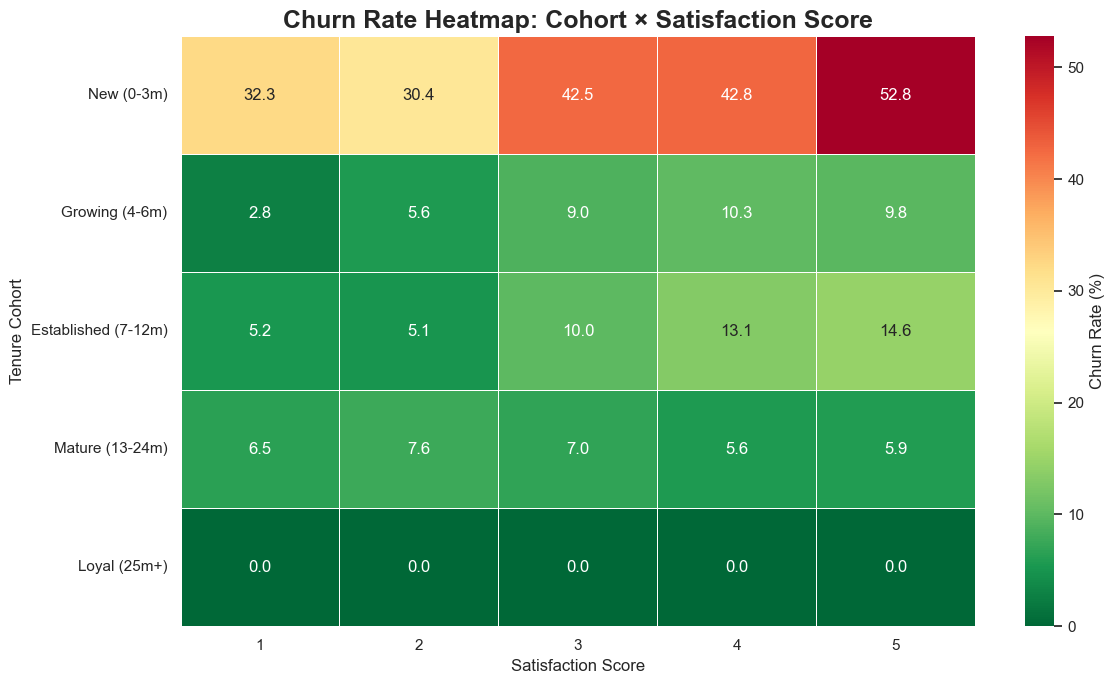

In [12]:
# Calculate churn rate by Tenure Cohort and Satisfaction Score
cohort_satisfaction = (
    df.groupby(
        ["TenureCohort", "SatisfactionScore"],
        observed=False
    )["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

# Convert the result into a matrix
satisfaction_heatmap = cohort_satisfaction.pivot(
    index="TenureCohort",
    columns="SatisfactionScore",
    values="Churn Rate"
)

# Create satisfaction heatmap
plt.figure(figsize=(12, 7))

sns.heatmap(
    satisfaction_heatmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Churn Rate Heatmap: Cohort × Satisfaction Score",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Satisfaction Score")
plt.ylabel("Tenure Cohort")

plt.tight_layout()

# Save heatmap
plt.savefig(
    f"{IMAGE_FOLDER}/cohort_satisfaction_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

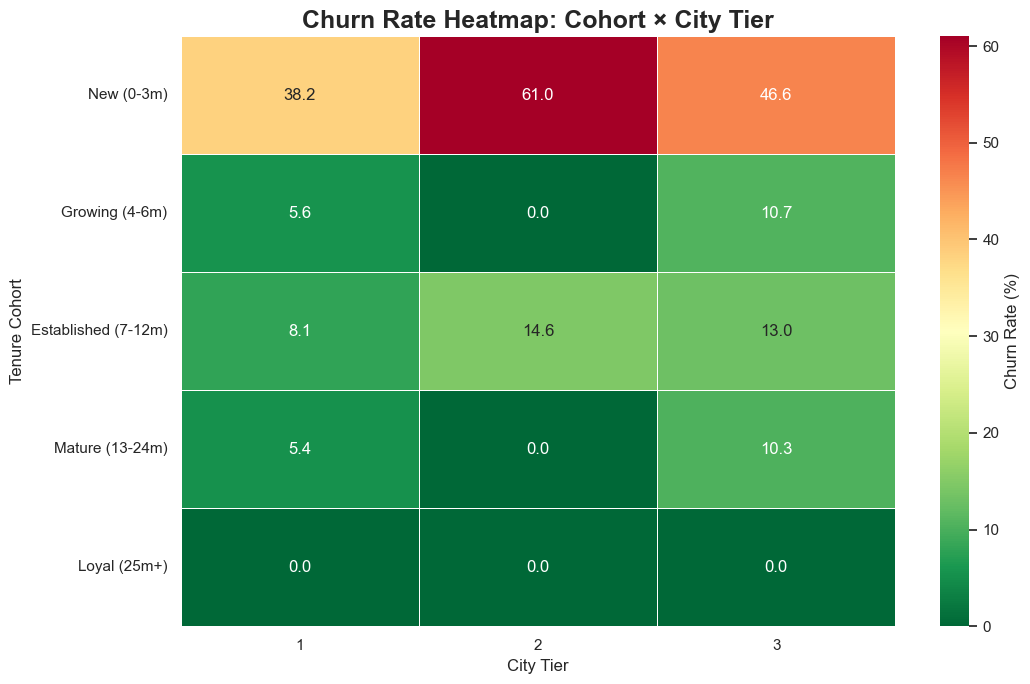

In [13]:
# Calculate churn rate by Tenure Cohort and City Tier
cohort_city = (
    df.groupby(
        ["TenureCohort", "CityTier"],
        observed=False
    )["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

# Convert the result into a matrix
city_heatmap = cohort_city.pivot(
    index="TenureCohort",
    columns="CityTier",
    values="Churn Rate"
)

# Create City Tier heatmap
plt.figure(figsize=(11, 7))

sns.heatmap(
    city_heatmap,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title(
    "Churn Rate Heatmap: Cohort × City Tier",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("City Tier")
plt.ylabel("Tenure Cohort")

plt.tight_layout()

# Save heatmap
plt.savefig(
    f"{IMAGE_FOLDER}/cohort_citytier_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 5: Customer Lifecycle Journey

This section tells the customer behavior story across lifecycle stages.

We compare:

- Average Order Count
- Average Cashback Amount
- Average Days Since Last Order
- Average Satisfaction Score

The objective is to understand how customer engagement changes as customers
move from New to Loyal.

,Avg_OrderCount,Avg_CashbackAmount,Avg_DaySinceLastOrder,Avg_SatisfactionScore
TenureCohort,,,,
New (0-3m),2.32,155.66,3.47,3.18
Growing (4-6m),2.97,169.91,4.57,2.94
Established (7-12m),2.75,163.31,4.38,2.99
Mature (13-24m),3.70,204.92,5.32,3.09
Loyal (25m+),3.55,222.34,5.26,3.05


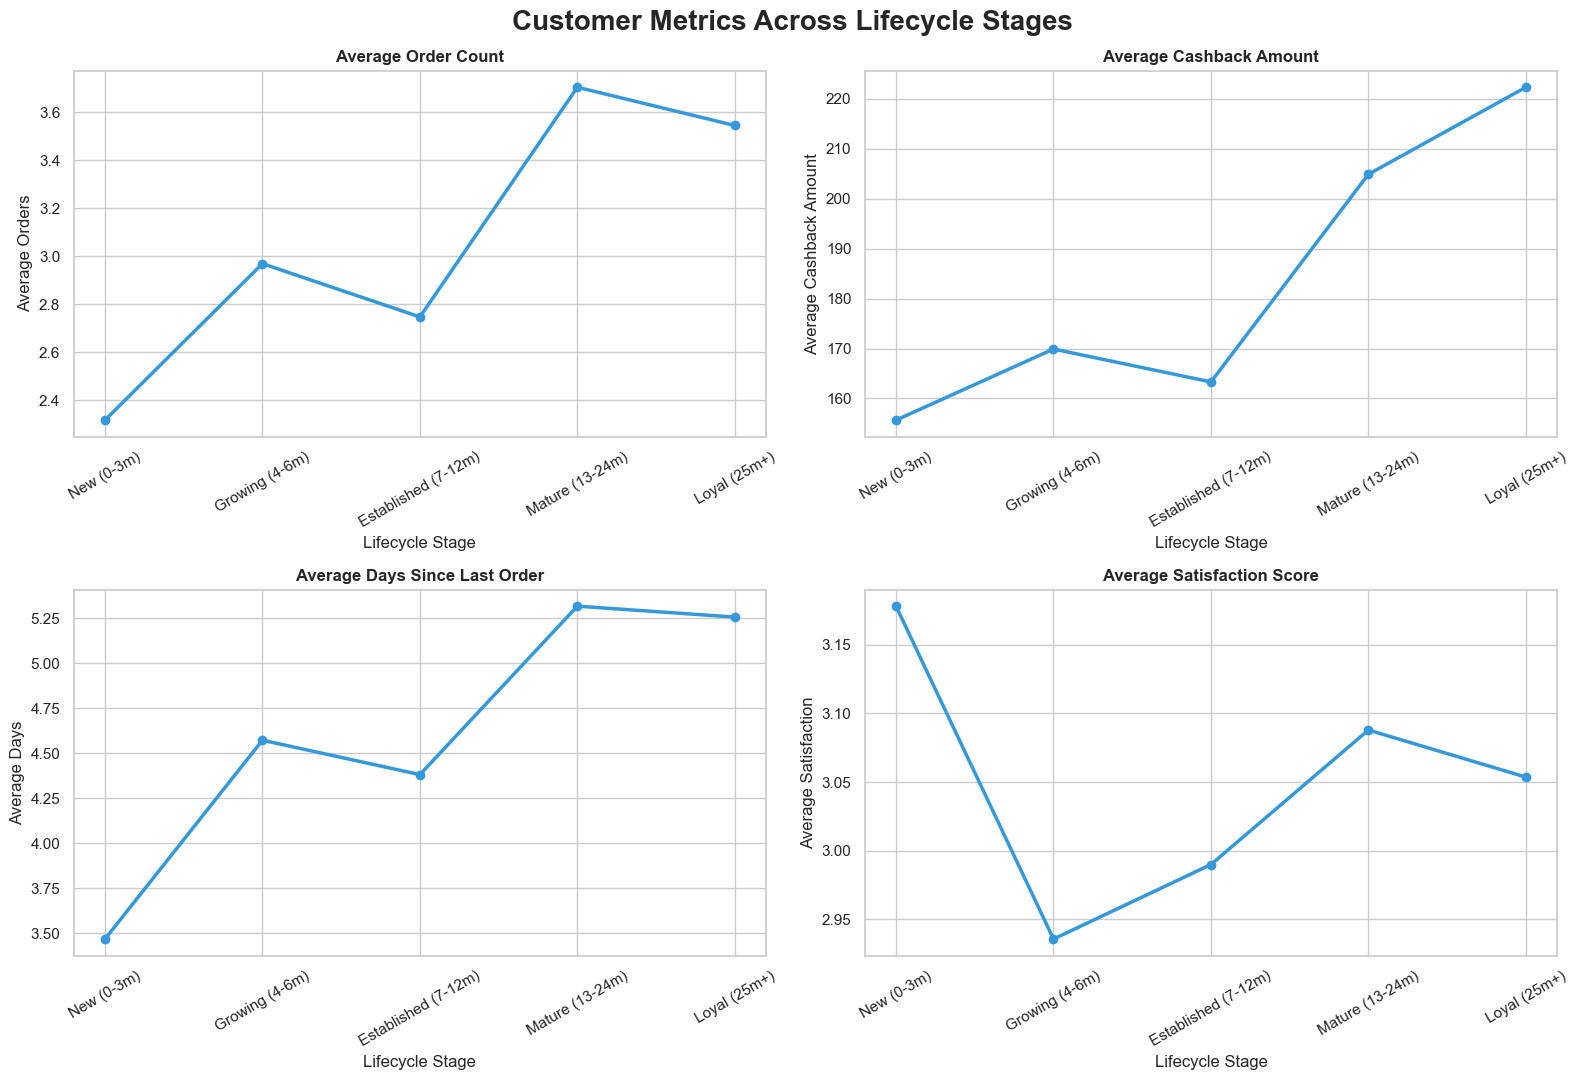

In [14]:
# Calculate average customer metrics for each lifecycle cohort
lifecycle_metrics = (
    df.groupby("TenureCohort", observed=False)
    .agg(
        Avg_OrderCount=("OrderCount", "mean"),
        Avg_CashbackAmount=("CashbackAmount", "mean"),
        Avg_DaySinceLastOrder=("DaySinceLastOrder", "mean"),
        Avg_SatisfactionScore=("SatisfactionScore", "mean")
    )
)

# Display lifecycle metrics
display(lifecycle_metrics.round(2))

# Create a 2x2 visualization
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

# Convert cohort labels to strings
cohort_labels = lifecycle_metrics.index.astype(str)

# Plot average order count
axes[0, 0].plot(
    cohort_labels,
    lifecycle_metrics["Avg_OrderCount"],
    marker="o",
    linewidth=2.5,
    color=NEUTRAL_COLOR
)
axes[0, 0].set_title("Average Order Count", fontweight="bold")
axes[0, 0].set_xlabel("Lifecycle Stage")
axes[0, 0].set_ylabel("Average Orders")

# Plot average cashback
axes[0, 1].plot(
    cohort_labels,
    lifecycle_metrics["Avg_CashbackAmount"],
    marker="o",
    linewidth=2.5,
    color=NEUTRAL_COLOR
)
axes[0, 1].set_title("Average Cashback Amount", fontweight="bold")
axes[0, 1].set_xlabel("Lifecycle Stage")
axes[0, 1].set_ylabel("Average Cashback Amount")

# Plot average days since last order
axes[1, 0].plot(
    cohort_labels,
    lifecycle_metrics["Avg_DaySinceLastOrder"],
    marker="o",
    linewidth=2.5,
    color=NEUTRAL_COLOR
)
axes[1, 0].set_title("Average Days Since Last Order", fontweight="bold")
axes[1, 0].set_xlabel("Lifecycle Stage")
axes[1, 0].set_ylabel("Average Days")

# Plot average satisfaction
axes[1, 1].plot(
    cohort_labels,
    lifecycle_metrics["Avg_SatisfactionScore"],
    marker="o",
    linewidth=2.5,
    color=NEUTRAL_COLOR
)
axes[1, 1].set_title("Average Satisfaction Score", fontweight="bold")
axes[1, 1].set_xlabel("Lifecycle Stage")
axes[1, 1].set_ylabel("Average Satisfaction")

# Rotate cohort labels for readability
for axis in axes.flat:
    axis.tick_params(axis="x", rotation=30)

# Add overall title
fig.suptitle(
    "Customer Metrics Across Lifecycle Stages",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

# Save lifecycle visualization
plt.savefig(
    f"{IMAGE_FOLDER}/customer_lifecycle_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Business Insight

The lifecycle curves should be read together rather than independently.

For example:

- Increasing OrderCount → stronger engagement
- Increasing DaySinceLastOrder → potentially weaker recent engagement
- Changing Satisfaction → changing customer experience
- Changing Cashback → changing monetary/customer incentive behavior

The goal is to understand **how the customer relationship evolves**, not simply
to identify one isolated metric.

## Section 6: Retention Rate Analysis

Retention rate is calculated as:

**Retention Rate = 100 - Churn Rate**

The retention curve shows how customer retention changes across lifecycle stages.

We also identify the largest retention drop between consecutive cohorts.

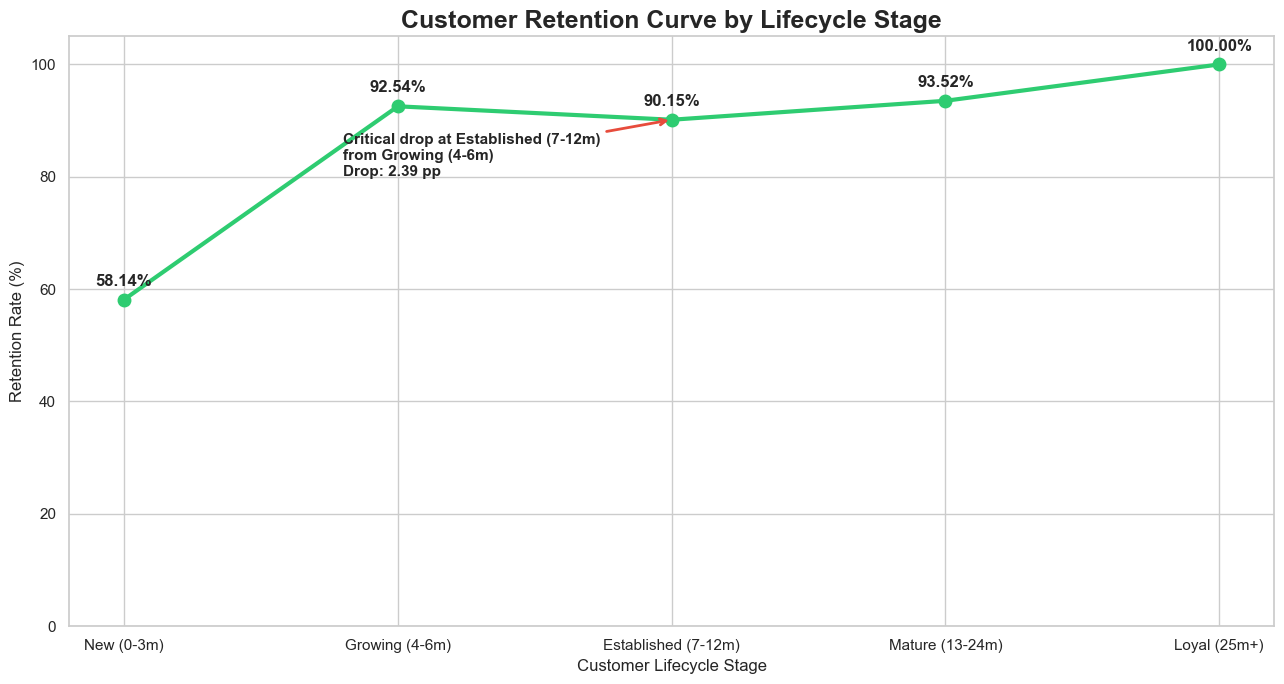

Largest retention drop occurs between Growing (4-6m) and Established (7-12m): 2.39 percentage points.


In [16]:
# Extract retention rates
retention_rates = cohort_summary["Retention_Rate"]

# Calculate the change between consecutive lifecycle stages
retention_changes = retention_rates.diff()

# Find the largest negative change
largest_retention_drop = retention_changes.min()
largest_drop_position = retention_changes.idxmin()

# Identify the previous cohort
cohort_position = list(retention_rates.index).index(
    largest_drop_position
)

previous_cohort = retention_rates.index[cohort_position - 1]

# Create retention curve
plt.figure(figsize=(13, 7))

plt.plot(
    retention_rates.index.astype(str),
    retention_rates.values,
    marker="o",
    markersize=9,
    linewidth=3,
    color=RETAINED_COLOR
)

# Add percentage labels
for index, value in enumerate(retention_rates.values):
    plt.annotate(
        f"{value:.2f}%",
        (
            index,
            value
        ),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontweight="bold"
    )

# Highlight the largest retention drop
plt.annotate(
    f"Critical drop at {largest_drop_position}\n"
    f"from {previous_cohort}\n"
    f"Drop: {abs(largest_retention_drop):.2f} pp",
    xy=(
        cohort_position,
        retention_rates.iloc[cohort_position]
    ),
    xytext=(cohort_position - 1.2, retention_rates.iloc[cohort_position] - 10),
    arrowprops=dict(
        arrowstyle="->",
        color=CHURN_COLOR,
        linewidth=2
    ),
    fontsize=11,
    fontweight="bold"
)

plt.title(
    "Customer Retention Curve by Lifecycle Stage",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Customer Lifecycle Stage")
plt.ylabel("Retention Rate (%)")
plt.ylim(0, 105)

plt.tight_layout()

# Save retention curve
plt.savefig(
    f"{IMAGE_FOLDER}/retention_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Largest retention drop occurs between "
    f"{previous_cohort} and {largest_drop_position}: "
    f"{abs(largest_retention_drop):.2f} percentage points."
)

## Section 7: Survival-Style Analysis

### Important Analytical Limitation

This dataset does not contain customer signup dates or individual customer
observation periods.

Therefore, a true Kaplan-Meier survival curve cannot be calculated.

Instead, this section creates a **survival-style cross-sectional view**:

For each tenure month:

- % of customers who are currently churned
- % of customers who are currently retained

This answers:

**"Among customers at this tenure level, what proportion is currently retained?"**

It should not be interpreted as a true time-to-event survival estimate.

,Total_Customers,Churned_Customers,Churn Rate %,Retention Rate %
Tenure,,,,
0.00,508,272,53.54,46.46
1.00,690,349,50.58,49.42
2.00,167,14,8.38,91.62
3.00,195,18,9.23,90.77
4.00,203,20,9.85,90.15
5.00,204,16,7.84,92.16
6.00,183,8,4.37,95.63
7.00,221,16,7.24,92.76
8.00,263,16,6.08,93.92


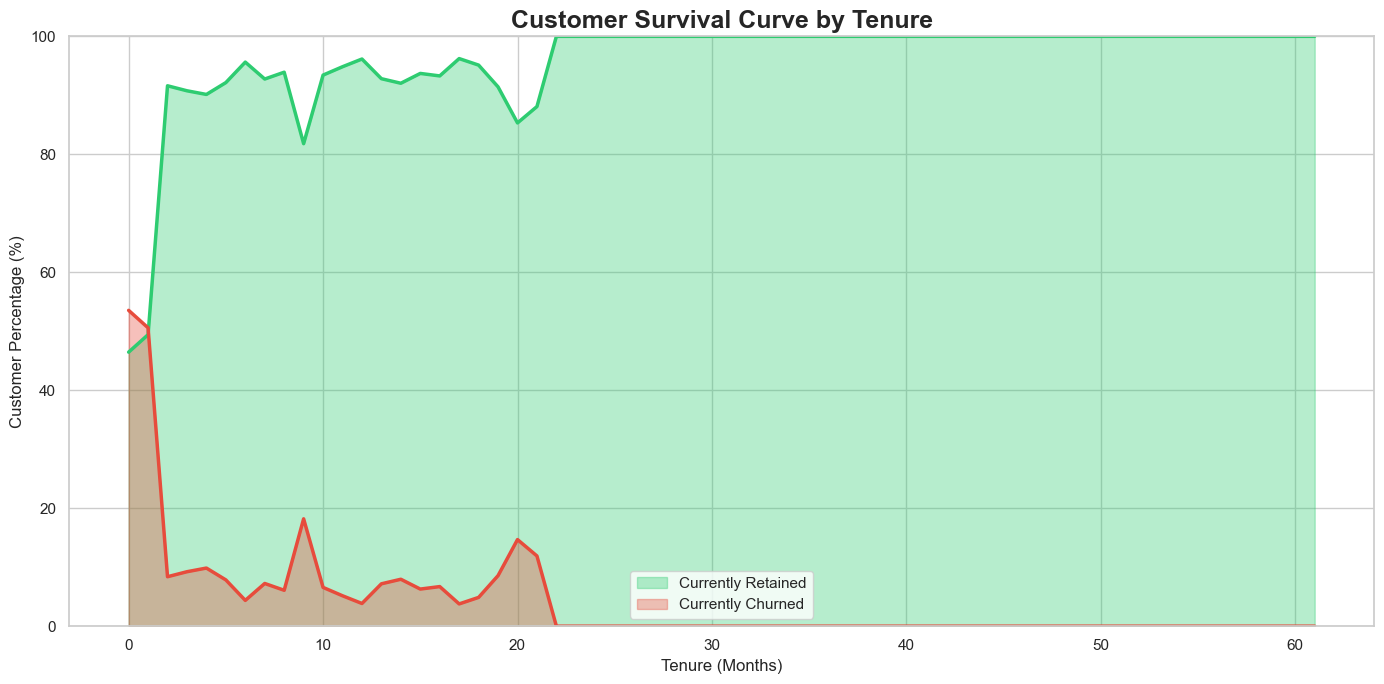

In [17]:
# Aggregate customer churn status by individual tenure month
monthly_survival = (
    df.groupby("Tenure")["Churn"]
    .agg(
        Total_Customers="count",
        Churned_Customers="sum"
    )
)

# Calculate current churn percentage at each tenure month
monthly_survival["Churn Rate %"] = (
    monthly_survival["Churned_Customers"] /
    monthly_survival["Total_Customers"] * 100
)

# Calculate current retention percentage
monthly_survival["Retention Rate %"] = (
    100 - monthly_survival["Churn Rate %"]
)

# Sort tenure months
monthly_survival = monthly_survival.sort_index()

# Display first records
display(monthly_survival.head(15).round(2))

# Create survival-style area chart
plt.figure(figsize=(14, 7))

plt.fill_between(
    monthly_survival.index,
    monthly_survival["Retention Rate %"],
    alpha=0.35,
    color=RETAINED_COLOR,
    label="Currently Retained"
)

plt.fill_between(
    monthly_survival.index,
    0,
    monthly_survival["Churn Rate %"],
    alpha=0.35,
    color=CHURN_COLOR,
    label="Currently Churned"
)

# Add retention line
plt.plot(
    monthly_survival.index,
    monthly_survival["Retention Rate %"],
    color=RETAINED_COLOR,
    linewidth=2.5
)

# Add churn line
plt.plot(
    monthly_survival.index,
    monthly_survival["Churn Rate %"],
    color=CHURN_COLOR,
    linewidth=2.5
)

plt.title(
    "Customer Survival Curve by Tenure",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Tenure (Months)")
plt.ylabel("Customer Percentage (%)")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()

# Save survival-style chart
plt.savefig(
    f"{IMAGE_FOLDER}/customer_survival_style_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 8: Cohort × Complaint Deep Dive

Complaints can be especially important during the early customer lifecycle.

We compare:

- New customers who complain
- New customers who do not complain
- Loyal customers who complain
- Loyal customers who do not complain

This helps identify whether **new + complaint** represents a particularly
high-risk combination.

,TenureCohort,Complaint Status,Churn Rate
0,New (0-3m),No Complaint,29.67
1,New (0-3m),Complaint,66.09
2,Growing (4-6m),No Complaint,3.09
3,Growing (4-6m),Complaint,21.90
4,Established (7-12m),No Complaint,6.37
5,Established (7-12m),Complaint,19.95
6,Mature (13-24m),No Complaint,4.08
7,Mature (13-24m),Complaint,12.56
8,Loyal (25m+),No Complaint,0.00
9,Loyal (25m+),Complaint,0.00


New customers who complain churn at 66.09%.
Loyal customers who complain churn at 0.00%.


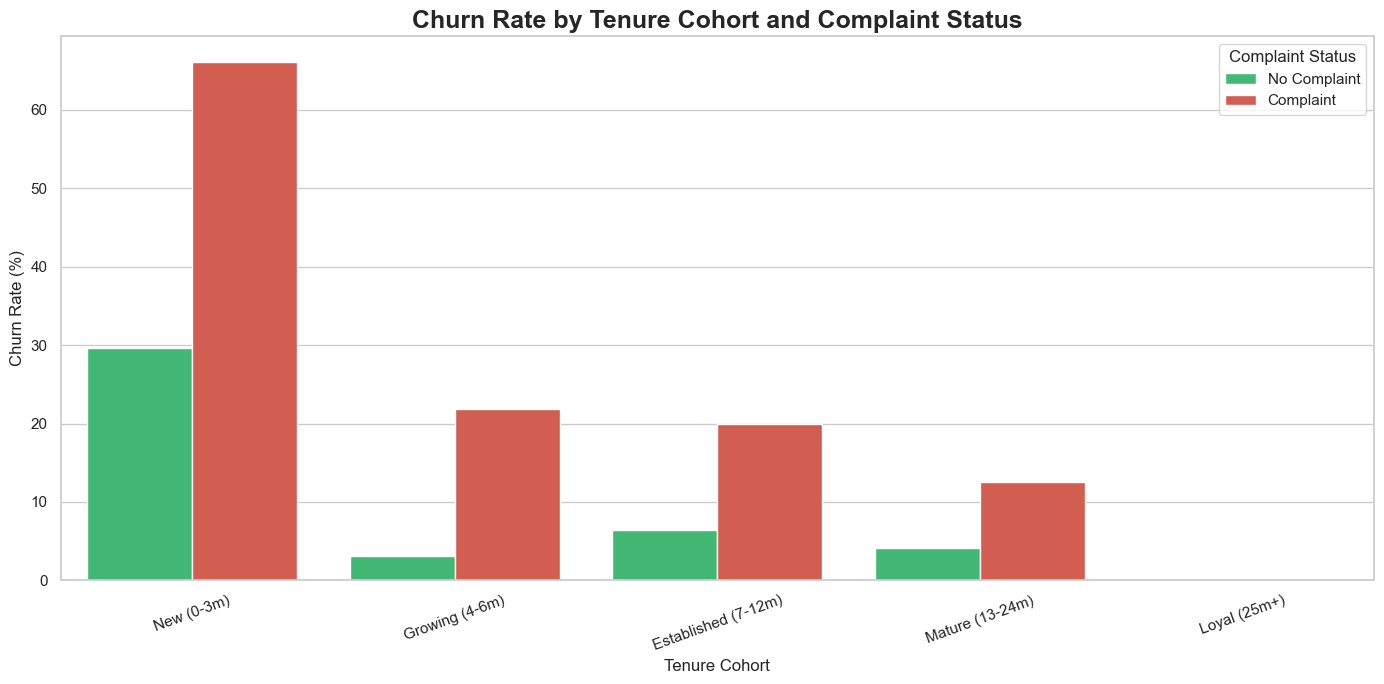

In [19]:
# Create cross-tabulation of Tenure Cohort, Complaint and Churn
cohort_complaint_table = (
    df.groupby(
        ["TenureCohort", "Complain", "Churn"],
        observed=False
    )
    .size()
    .reset_index(name="Customer Count")
)

# Calculate churn rate within each cohort and complaint group
cohort_complaint_churn = (
    df.groupby(
        ["TenureCohort", "Complain"],
        observed=False
    )["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

# Add readable complaint labels
cohort_complaint_churn["Complaint Status"] = (
    cohort_complaint_churn["Complain"]
    .map({
        0: "No Complaint",
        1: "Complaint"
    })
)

# Display cross-analysis
display(
    cohort_complaint_churn[
        [
            "TenureCohort",
            "Complaint Status",
            "Churn Rate"
        ]
    ].round(2)
)

# Extract new-customer complaint churn
new_complaint_churn = cohort_complaint_churn.loc[
    (cohort_complaint_churn["TenureCohort"] == "New (0-3m)") &
    (cohort_complaint_churn["Complain"] == 1),
    "Churn Rate"
]

# Extract loyal-customer complaint churn
loyal_complaint_churn = cohort_complaint_churn.loc[
    (cohort_complaint_churn["TenureCohort"] == "Loyal (25m+)") &
    (cohort_complaint_churn["Complain"] == 1),
    "Churn Rate"
]

# Safely extract values
new_complaint_churn_rate = (
    new_complaint_churn.iloc[0]
    if len(new_complaint_churn) > 0
    else np.nan
)

loyal_complaint_churn_rate = (
    loyal_complaint_churn.iloc[0]
    if len(loyal_complaint_churn) > 0
    else np.nan
)

print(
    f"New customers who complain churn at "
    f"{new_complaint_churn_rate:.2f}%."
)

print(
    f"Loyal customers who complain churn at "
    f"{loyal_complaint_churn_rate:.2f}%."
)

# Create grouped bar chart
plt.figure(figsize=(14, 7))

sns.barplot(
    data=cohort_complaint_churn,
    x="TenureCohort",
    y="Churn Rate",
    hue="Complaint Status",
    palette={
        "No Complaint": RETAINED_COLOR,
        "Complaint": CHURN_COLOR
    }
)

plt.title(
    "Churn Rate by Tenure Cohort and Complaint Status",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Tenure Cohort")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.legend(title="Complaint Status")

plt.tight_layout()

# Save chart
plt.savefig(
    f"{IMAGE_FOLDER}/cohort_complaint_churn.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Section 9: Customer Risk Segments ⭐

Based on the lifecycle patterns identified above, customers are assigned
to practical retention risk segments.

### Risk Rules

🔴 **CRITICAL RISK**
- New customer
- Has complained
- Low satisfaction (Score <= 2)

🟠 **HIGH RISK**
- New customer
- No recent order activity
- DaySinceLastOrder > 30 days

🟡 **MEDIUM RISK**
- Growing customer
- Low satisfaction (Score <= 2)

🟢 **LOW RISK**
- Mature or Loyal customer
- High satisfaction (Score >= 4)
- No complaint

Customers who do not satisfy one of these explicit rules are classified as
**Standard Risk** so that every customer remains represented in the output.

Revenue at risk is represented using **CashbackAmount as a monetary proxy**.
This is not actual revenue and should not be described as company revenue.

In [20]:
# Create a working copy so the cleaned master dataset is not overwritten
risk_data = df.copy()

# Define boolean conditions for each risk segment
critical_condition = (
    risk_data["TenureCohort"].eq("New (0-3m)") &
    risk_data["Complain"].eq(1) &
    risk_data["SatisfactionScore"].le(2)
)

high_condition = (
    risk_data["TenureCohort"].eq("New (0-3m)") &
    risk_data["DaySinceLastOrder"].gt(30)
)

medium_condition = (
    risk_data["TenureCohort"].eq("Growing (4-6m)") &
    risk_data["SatisfactionScore"].le(2)
)

low_condition = (
    risk_data["TenureCohort"].isin(
        ["Mature (13-24m)", "Loyal (25m+)"]
    ) &
    risk_data["SatisfactionScore"].ge(4) &
    risk_data["Complain"].eq(0)
)

# Assign risk levels using ordered priority
risk_data["RiskLevel"] = np.select(
    [
        critical_condition,
        high_condition,
        medium_condition,
        low_condition
    ],
    [
        "CRITICAL RISK",
        "HIGH RISK",
        "MEDIUM RISK",
        "LOW RISK"
    ],
    default="STANDARD RISK"
)

# Define risk ordering for reports and charts
risk_order = [
    "CRITICAL RISK",
    "HIGH RISK",
    "MEDIUM RISK",
    "LOW RISK",
    "STANDARD RISK"
]

# Convert RiskLevel into ordered category
risk_data["RiskLevel"] = pd.Categorical(
    risk_data["RiskLevel"],
    categories=risk_order,
    ordered=True
)

# Create risk summary
risk_summary = (
    risk_data.groupby(
        "RiskLevel",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "count"),
        Churned=("Churn", "sum"),
        Churn_Rate=("Churn", "mean"),
        Cashback_At_Risk=("CashbackAmount", "sum")
    )
)

# Convert churn rate into percentage
risk_summary["Churn_Rate"] = (
    risk_summary["Churn_Rate"] * 100
)

# Display risk summary
display(risk_summary.round(2))

,Customers,Churned,Churn_Rate,Cashback_At_Risk
RiskLevel,,,,
CRITICAL RISK,166,100,60.24,"25,631.85"
HIGH RISK,1,1,100.00,206.09
MEDIUM RISK,215,8,3.72,"36,403.52"
LOW RISK,545,5,0.92,"115,599.04"
STANDARD RISK,4703,834,17.73,"819,925.16"


### Risk Segment Visualization

The risk segment dashboard compares:

1. Customer volume
2. Churn rate
3. Cashback amount proxy at risk

This helps connect customer-level behavior with a business prioritization
framework.

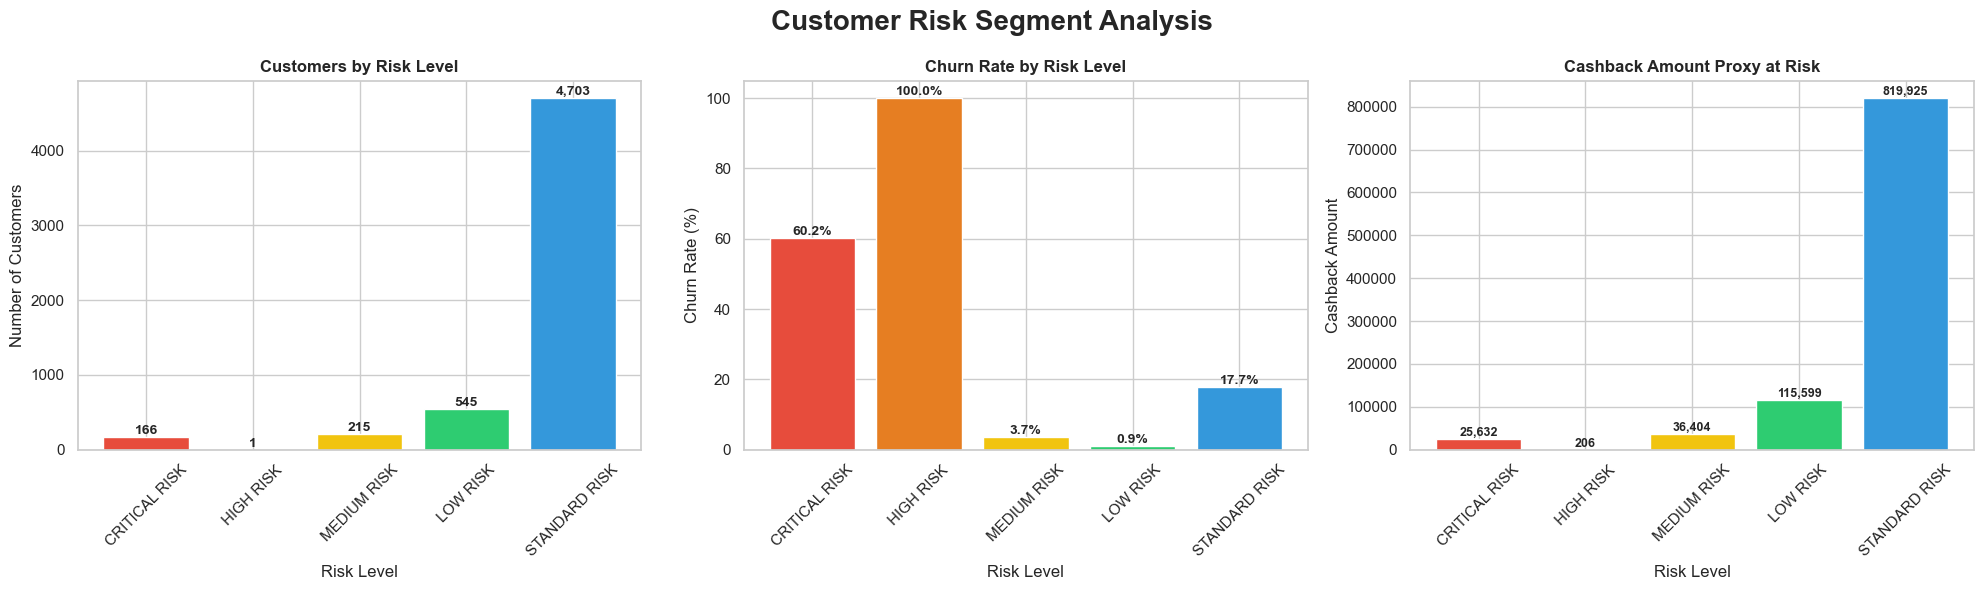

In [23]:
# Create figure for risk segment comparison
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6)
)

# Define colors for risk levels
risk_colors = [
    CHURN_COLOR,
    "#E67E22",
    "#F1C40F",
    RETAINED_COLOR,
    NEUTRAL_COLOR
]

# ---------------- Customer Count ----------------
bars = axes[0].bar(
    risk_summary.index.astype(str),
    risk_summary["Customers"],
    color=risk_colors
)

for bar in bars:
    height = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_title(
    "Customers by Risk Level",
    fontweight="bold"
)
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=45)

# ---------------- Churn Rate ----------------
bars = axes[1].bar(
    risk_summary.index.astype(str),
    risk_summary["Churn_Rate"],
    color=risk_colors
)

for bar in bars:
    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[1].set_title(
    "Churn Rate by Risk Level",
    fontweight="bold"
)
axes[1].set_xlabel("Risk Level")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

# ---------------- Cashback Proxy ----------------
bars = axes[2].bar(
    risk_summary.index.astype(str),
    risk_summary["Cashback_At_Risk"],
    color=risk_colors
)

for bar in bars:
    height = bar.get_height()

    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

axes[2].set_title(
    "Cashback Amount Proxy at Risk",
    fontweight="bold"
)
axes[2].set_xlabel("Risk Level")
axes[2].set_ylabel("Cashback Amount")
axes[2].tick_params(axis="x", rotation=45)

# Add overall title
fig.suptitle(
    "Customer Risk Segment Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

# Save risk dashboard
plt.savefig(
    f"{IMAGE_FOLDER}/customer_risk_segments.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Export Risk Segments for Notebook 4

The customer-level risk segmentation is exported so that Notebook 4 can use
the same segmentation for business reporting and dashboard development.

The export contains the original customer information plus:
- TenureCohort
- RiskLevel

This avoids recreating the risk logic manually in the next notebook.

In [25]:
# Define columns to export for downstream analysis
risk_export_columns = [
    "CustomerID",
    "Churn",
    "Tenure",
    "TenureCohort",
    "RiskLevel",
    "DaySinceLastOrder",
    "OrderCount",
    "CashbackAmount",
    "SatisfactionScore",
    "Complain",
    "CityTier",
    "Gender"
]

# Export customer-level risk segments
risk_data[risk_export_columns].to_csv(
    RISK_OUTPUT_PATH,
    index=False
)

# Confirm successful export
print("=" * 70)
print("RISK SEGMENT EXPORT COMPLETED")
print("=" * 70)
print(f"File Path : {RISK_OUTPUT_PATH}")
print(
    f"Rows      : "
    f"{len(risk_data):,}"
)
print(
    f"Columns   : "
    f"{len(risk_export_columns):,}"
)

print("\nExported Columns:")
for column in risk_export_columns:
    print(f"- {column}")

print("=" * 70)

RISK SEGMENT EXPORT COMPLETED
File Path : ../data/cleaned/customer_risk_segments.csv
Rows      : 5,630
Columns   : 12

Exported Columns:
- CustomerID
- Churn
- Tenure
- TenureCohort
- RiskLevel
- DaySinceLastOrder
- OrderCount
- CashbackAmount
- SatisfactionScore
- Complain
- CityTier
- Gender


## Section 11: Cohort Analysis Key Findings

The final section converts the cohort analysis into concise business findings.

The values are calculated dynamically from the dataset rather than manually
hard-coded.

This makes the notebook suitable for a portfolio project and easier to defend
during an interview.

In [26]:
# Identify highest churn cohort
highest_churn_cohort = cohort_summary["Churn_Rate"].idxmax()
highest_churn_cohort_rate = cohort_summary["Churn_Rate"].max()

# Identify lowest churn cohort
lowest_churn_cohort = cohort_summary["Churn_Rate"].idxmin()
lowest_churn_cohort_rate = cohort_summary["Churn_Rate"].min()

# Calculate percentage of churned customers who are new
churned_customers = df[df["Churn"] == 1]

new_churned_percentage = (
    churned_customers["TenureCohort"]
    .eq("New (0-3m)")
    .mean() * 100
)

# Identify biggest retention drop
largest_drop_value = abs(largest_retention_drop)

# Identify highest-risk explicit segment
critical_customers = risk_data[
    risk_data["RiskLevel"] == "CRITICAL RISK"
]

critical_customer_count = len(critical_customers)

critical_churn_rate = (
    critical_customers["Churn"].mean() * 100
    if critical_customer_count > 0
    else np.nan
)

# Identify strongest cohort × satisfaction combination
valid_satisfaction_cells = (
    cohort_satisfaction
    .dropna(subset=["Churn Rate"])
    .sort_values("Churn Rate", ascending=False)
)

if len(valid_satisfaction_cells) > 0:
    highest_risk_satisfaction_cell = valid_satisfaction_cells.iloc[0]
else:
    highest_risk_satisfaction_cell = None

# Print formatted findings
print("=" * 90)
print("                    COHORT ANALYSIS KEY FINDINGS")
print("=" * 90)

print(
    f"\n1. NEW CUSTOMERS"
    f"\n   {highest_churn_cohort} has the highest observed churn rate: "
    f"{highest_churn_cohort_rate:.2f}%."
)

print(
    f"\n2. LOYAL CUSTOMERS"
    f"\n   {lowest_churn_cohort} has the lowest observed churn rate: "
    f"{lowest_churn_cohort_rate:.2f}%."
)

print(
    f"\n3. EARLY-LIFECYCLE CHURN"
    f"\n   {new_churned_percentage:.2f}% of all churned customers "
    f"belong to the New (0-3m) cohort."
)

print(
    f"\n4. RETENTION DROP"
    f"\n   The largest observed retention drop occurs between "
    f"{previous_cohort} and {largest_drop_position}, "
    f"with a decline of {largest_drop_value:.2f} percentage points."
)

if not np.isnan(new_complaint_churn_rate):
    print(
        f"\n5. NEW + COMPLAINT RISK"
        f"\n   New customers who complain churn at "
        f"{new_complaint_churn_rate:.2f}%."
        f"\n   This combination should receive priority attention "
        f"in early-life retention campaigns."
    )
else:
    print(
        "\n5. NEW + COMPLAINT RISK"
        "\n   No matching customers were available for this segment."
    )

if highest_risk_satisfaction_cell is not None:
    print(
        f"\n6. HIGHEST COHORT × SATISFACTION RISK"
        f"\n   {highest_risk_satisfaction_cell['TenureCohort']} + "
        f"Satisfaction Score "
        f"{int(highest_risk_satisfaction_cell['SatisfactionScore'])} "
        f"shows the highest observed churn rate of "
        f"{highest_risk_satisfaction_cell['Churn Rate']:.2f}%."
    )

print("\n" + "=" * 90)
print("BUSINESS INTERPRETATION")
print("=" * 90)

print(
    "\nThe cohort analysis suggests that customer retention should be treated "
    "as a lifecycle problem rather than a single customer-level problem."
)

print(
    "\nThe earliest lifecycle stages deserve particular attention because "
    "customers who churn early represent customers who have not yet developed "
    "a strong relationship with the company."
)

print(
    "\nComplaint status and satisfaction provide additional signals that can "
    "help prioritize customers for proactive retention interventions."
)

print(
    "\nThe risk segmentation created in this notebook provides a practical "
    "bridge between descriptive analytics and business action."
)

print(
    "\nNotebook 3 — Cohort Analysis & Retention Curves completed successfully."
)

                    COHORT ANALYSIS KEY FINDINGS

1. NEW CUSTOMERS
   New (0-3m) has the highest observed churn rate: 41.86%.

2. LOYAL CUSTOMERS
   Loyal (25m+) has the lowest observed churn rate: 0.00%.

3. EARLY-LIFECYCLE CHURN
   68.88% of all churned customers belong to the New (0-3m) cohort.

4. RETENTION DROP
   The largest observed retention drop occurs between Growing (4-6m) and Established (7-12m), with a decline of 2.39 percentage points.

5. NEW + COMPLAINT RISK
   New customers who complain churn at 66.09%.
   This combination should receive priority attention in early-life retention campaigns.

6. HIGHEST COHORT × SATISFACTION RISK
   New (0-3m) + Satisfaction Score 5 shows the highest observed churn rate of 52.77%.

BUSINESS INTERPRETATION

The cohort analysis suggests that customer retention should be treated as a lifecycle problem rather than a single customer-level problem.

The earliest lifecycle stages deserve particular attention because customers who churn early r